In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
import src
import torch
from pathlib import Path 
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
set_seed(0) 

In [12]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_tm_attnpl_t_20250725-144830") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
model.eval() 

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/classifier_tm_s_20250704-154411/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_tm_attnpl_t', 'batch_size': 32, 'accumulation_steps': 4, 'warmup_ratio': 0.1, 'learning_rate': 0.0005, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.5, 'd_model': 128, 'd_rnn': 128, 'd_inner': 256, 'n_layers': 4, 'n_head': 8, 'd_k': 16, 'd_v': 16, 't_dropout': 0.1, 'rnn_dropout': 0, 'attn_type': 'flash', 'mlp_out': 1, 'mlp_dropout': 0.3, 'mlp_hdw': [256, 128, 64], 'dim': 1, 'epochs': 150, 'save_dir': 'checkpoints/clf_tm_attnpl_t_20250725-144830', 'cuda_id': 0, 'dataset': 'SCEDC', 'seed': 0, 'Mc': 2, 'Mf': 5, 'Twindow': 300, 'Tfore': 150, 'dt': 10, 'context_len': 1, 'split_by_time': True, 'use_sam

TaskModel(
  (base_model): BaseModel(
    (encoder): Transformer(
      (encoder): Encoder(
        (layer_stacks): ModuleDict(
          (default): ModuleList(
            (0-3): 4 x EncoderLayer(
              (slf_attn): MultiHeadAttention(
                (w_qs): Linear(in_features=128, out_features=128, bias=False)
                (w_ks): Linear(in_features=128, out_features=128, bias=False)
                (w_vs): Linear(in_features=128, out_features=128, bias=False)
                (fc): Linear(in_features=128, out_features=128, bias=True)
                (layer_norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
                (dropout): Dropout(p=0.1, inplace=False)
                (attn_modules): ModuleDict(
                  (full): FullAttention(
                    (dropout): Dropout(p=0.1, inplace=False)
                  )
                  (flash): FlashAttentionWrapper()
                )
              )
              (pos_ffn): PositionwiseFeedForward(
     

In [14]:
from src.data.preparation import prepare_data
base_dir = Path(f"../data/{args.dataset}")
df, train_loader, val_loader, test_loader,dataset = prepare_data(args, base_dir)

CSV files found: ['SCEDC.csv', 'processed_SCEDC.csv', 'catalog.csv']
[✔] Loading cached data from: ../data/SCEDC/processed/classifier/classifier_Mc_2_Mf_5_Tfore_150_Twindow_300_context_len_1_dt_10.pkl
lengths of samples: min=707, max=16904, avg=2530.73
Number of positive samples: 652
Number of negative samples: 381
Positive samples: 572, Negative samples: 254
Total samples: 826, Positive ratio: 0.69, Negative ratio: 0.31
Positive samples: 35, Negative samples: 68
Total samples: 103, Positive ratio: 0.34, Negative ratio: 0.66
Positive samples: 45, Negative samples: 59
Total samples: 104, Positive ratio: 0.43, Negative ratio: 0.57


In [15]:
for i, (x, y) in enumerate(test_loader):
    x = x.to(device)
    y = y.to(device)
    break

In [16]:
model(x)

tensor([-0.4685, -0.4700, -0.4730, -0.4747, -0.4738, -0.4691, -0.4560, -0.4535,
        -0.4544, -0.4495, -0.4564, -0.4404, -0.4455, -0.4420, -0.4453, -0.4421,
        -0.4404, -0.4423, -0.4290, -0.4153, -0.4313, -0.4304, -0.4288, -0.4366,
        -0.4410, -0.4510, -0.4480, -0.4180, -0.4160, -0.4256, -0.4381, -0.4500],
       device='cuda:0', grad_fn=<SqueezeBackward1>)

In [17]:
attn_weights = torch.load("../tests/attn_weights.pt")

/tmp/ipykernel_72218/634280326.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attn_weights = torch.load("../tests/attn_weights.pt")


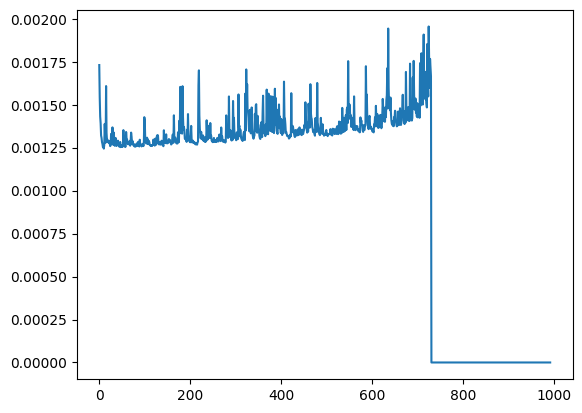

In [18]:
plt.plot(attn_weights[0].cpu().detach().numpy())

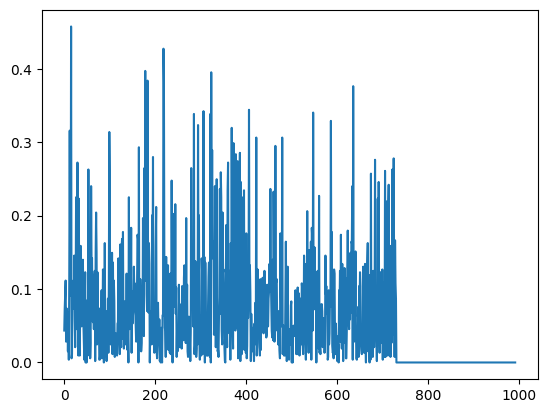

In [19]:
plt.plot(x[0,:,2:3].squeeze(-1).cpu().detach().numpy())

In [22]:
condition = x[0, :, 2:3] == 0
first_pad_index = np.argmax(condition.cpu().detach().numpy())
print(f"First padding index: {first_pad_index}")

First padding index: 47


In [21]:
condition = attn_weights[0] == 0
first_pad_index = np.argmax(condition.cpu().detach().numpy())
print(f"First padding index: {first_pad_index}")

First padding index: 730


In [51]:
import torch
L =32
input  = torch.zeros((1,L, 128)).to(device)
t = torch.linspace(0, 1, steps=L).to(device)
non_pad_mask = torch.ones((1, L)).to(device)
feature = {"event_time": t.unsqueeze(0).to(device),}

In [55]:
model.extractor.pool.attn_fc(torch.cat([input,t[None,:,None]], dim=-1)).squeeze()

tensor([0.0186, 0.0199, 0.0211, 0.0224, 0.0237, 0.0249, 0.0262, 0.0275, 0.0288,
        0.0300, 0.0313, 0.0326, 0.0338, 0.0351, 0.0364, 0.0376, 0.0389, 0.0402,
        0.0415, 0.0427, 0.0440, 0.0453, 0.0465, 0.0478, 0.0491, 0.0503, 0.0516,
        0.0529, 0.0541, 0.0554, 0.0567, 0.0579], device='cuda:0',
       grad_fn=<SqueezeBackward0>)

In [56]:
print(t)

tensor([0.0000, 0.0323, 0.0645, 0.0968, 0.1290, 0.1613, 0.1935, 0.2258, 0.2581,
        0.2903, 0.3226, 0.3548, 0.3871, 0.4194, 0.4516, 0.4839, 0.5161, 0.5484,
        0.5806, 0.6129, 0.6452, 0.6774, 0.7097, 0.7419, 0.7742, 0.8065, 0.8387,
        0.8710, 0.9032, 0.9355, 0.9677, 1.0000], device='cuda:0')
